In [24]:
import os
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict, Annotated, List, Literal
import operator
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from IPython.display import Image, display

In [25]:
load_dotenv()

True

In [26]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [27]:
class SentimentState(TypedDict):
    text: str
    score: int
    pos: str
    neg: str
    neutral: str
    final_output: str

In [28]:
def sentiment_score(state: SentimentState):
    text = state["text"]
    response = llm.invoke(
        f"Analyze the sentiment of the following text and provide a score from 1 to 10, where 1 is very negative and 10 is very positive: {text}"
    )
    score = int(response.content.strip())
    return {"score": score}

In [ ]:
def conditional_node(
    state: SentimentState,
) -> Literal["positive_node", "negative_node", "neutral_node"]:
    score = state["score"]

    if score >= 7:
        return "positive_node"
    elif score <= 4:
        return "negative_node"
    else:
        return "neutral_node"

In [30]:
def positive_node(state: SentimentState):
    return {"final_output": f"The text is positive: {state['pos']}"}

In [31]:
def negative_node(state: SentimentState):
    return {"final_output": f"The text is negative: {state['neg']}"}

In [32]:
def neutral_node(state: SentimentState):
    return {"final_output": f"The text is neutral: {state['neutral']}"}

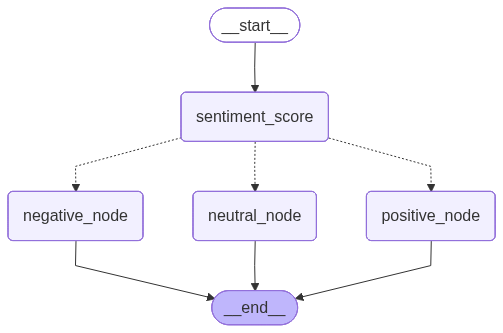

In [38]:
workflow = StateGraph(SentimentState)
workflow.add_node("sentiment_score", sentiment_score)
workflow.add_node("positive_node", positive_node)
workflow.add_node("negative_node", negative_node)
workflow.add_node("neutral_node", neutral_node)

workflow.add_edge(START, "sentiment_score")

workflow.add_conditional_edges(
    "sentiment_score",
    conditional_node,
    {
        "positive_node": "positive_node",
        "negative_node": "negative_node",
        "neutral_node": "neutral_node",
    },
)
workflow.add_edge("positive_node", END)
workflow.add_edge("negative_node", END)
workflow.add_edge("neutral_node", END)
workflow.compile()